<a href="https://colab.research.google.com/github/Farida02/learn-data-science-/blob/NLP/V2_Text_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Teks Analitik

Tujuan dari teks analitik adalah mendapatkan informasi dari data teks yang dimiliki. Berikut merupakan langkah-langkah dalam melakukan teks analitik
1. Menemukan permasalahan dan kemungkinan solusi yang dapat diberikan
2. EDA (Exploratory Data Analysis)
3. Feature Engineering
4. Modelling
5. Prediksi dari model

## 1. Menemukan permasalahan dan kemungkinan solusi yang dapat diberikan.
### 1.1 Input Data
Pada kesempatan ini akan di gunakan google colaboratory, input data dilakukan dengan membaca data yang terdapat dalam google drive, oleh karena itu pastikan bahwa google colab anda sudah tersambung dengan google drive anda.

In [1]:
# Mengakses google drive ke dalam google colaboratory
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


Untuk mengakses data yang akan digunakan maka pastikan bahwa anda mengetahui letak data anda. Dapat dilakukan dengan menambahkan variabel baru yang menunjukkan letak data anda, atau dengan cara seperti dibawah ini dimana memposisikan notebook sama dengan data yang akan digunakan.

In [3]:
# Letakkan posisi notebook dalam folder yang smaa dengan data yang akan digunakan
%cd "/content/gdrive/MyDrive/NLP-Copy/Notebook-NLP1/"

# Mengkonfirmasi daftar file dalam folder yang telah dipilih
%ls

/content/gdrive/MyDrive/NLP-Copy/Notebook-NLP1
'IMDB Dataset.csv'


In [4]:
# List the contents of your Google Drive
%ls "/content/gdrive/MyDrive/"

'221111005 - ResumeSoftwareTesting.gdoc'
'221111005 - Tugas1.gdoc'
 221111005-Tugas6.gdoc
'Analisis Komprehensif Polemik Ijazah Presiden Joko Widodo: Lensa Hukum, Politik, dan Disinformasi.gdoc'
'Anda adalah seorang peneliti analitis dengan peng....gsheet'
 ApplicationLatter.gdoc
'baby-steps (1).gdoc'
'baby-steps (2).gdoc'
'baby-steps (3).gdoc'
'baby-steps (4).gdoc'
'baby-steps (5).gdoc'
'baby-steps (6).gdoc'
'baby-steps (7).gdoc'
 baby-steps.gdoc
 BahasaIndonesia_Abstrak.docx
'Berdasarkan spreadsheet yang kamu buat, untuk bag....gsheet'
 blockDiagram.drawio
'Buat dalam bentuk paragraf paragraf.gdoc'
'Buatkan dalam bentuk tabel saja literatur di atas.gsheet'
'Buatkan data dummy sendiri.gsheet'
'Buatkan saya Resume sesuai dengan outline di atas... (1).gdoc'
'Buatkan saya Resume sesuai dengan outline di atas....gdoc'
'Coba semua penjelasan di masukkan ke dalam Spread....gsheet'
'Colab Notebooks'/
 config.zip
 Contoh-Nyata.gdoc
'Contoh Valid Time dalam kehidupan sehari-hari dan jelaskan? 

In [5]:
%ls "/content/gdrive/MyDrive/NLP-Copy/Notebook-NLP1/"

'IMDB Dataset.csv'


#### 1.1.1 Library yang sering digunakan dalam teks analitik
##### **NLTK**
The Natural Language Toolkit (NLTK) merupakan salah satu library yang terdapat di python untuk keperluan NLP (Natural Language Processing). Dalam NLTK terdapat beberapa corpus dengan beberapa bahasa diantaranya :
1. Tokenization
2. Stopword
3. Stemming
4. Lemmatization
5. Word2Vec

Selain yang disebutkan diatas masih banyak lagi diantaranya, untuk mencari lebih lanjut dapat mengunjungi link berikut http://www.nltk.org. NLTK termasuk library yang banyak digunakan.


##### **spaCy**
Sama seperti dengan NLTK, spaCy merupakan library untuk keperluan NLP, perbedaannya dengan NLTK selain pada corpusnya adalah spaCy biasanya banyak digunakan oleh developer. Selain itu spaCy lebih cenderung ke arah semantik, biasanya spaCy lebih banyak digunakan untuk mengerjakan
1. POS Tagging
2. NER
3. Dependency Parsing<br>


https://spacy.io/


##### **Gensim**
Gensim merupakan salah satu library dalam pengembangan NLP namun lebih mengarah ke kebutuhan seperti topic modelling, document indexing, dan similarity retrieval dimana membutuhkan resource yang besar. Gensim sering kali digunakan untuk permasalahan yang sedikit komplek dan juga dalam kebutuhan deep learning. https://radimrehurek.com/gensim/


##### **TextBlob**
TextBlob adalah library yang hampir sama seperti NLTK. Library ini biasanya banyak digunakan oleh orang-orang yang belajar basic dari NLP, kebutuhan yang ditawarkan sama yaitu untuk keperluan tokenization, pos tagging, lemmatization dan lainnya. Sejauh ini TextBlob banyak digunakan untuk mengerjakan sentimen analisis. Untuk lebih lengkapnya dapat di akses di https://textblob.readthedocs.io/en/dev/


##### **Sastrawi**
Library ini sedikit berbeda dengan library sebelumnya yang terdapat beberapa bahasa didalam-nya, sastrawi dikembangkan khusus untuk bahasa Indonesia dan corpusnya terbatas. Saat ini teks analisis untuk bahasa Indonesia semakin banyak diminati, oleh karena itu library ini sangat membantu terutama dalam proses stemming. Lebih lengkapnya dapat dilihat pada link berikut https://github.com/har07/PySastrawi


##### **Regex**
Regular expressions atau yang sering juga disebut RE atau Regex adalah library yang digunakan untuk membaca atau mendeteksi pola yang diinginkan. Regex ini banyak digunakan dalam proses data preprocessing untuk memanipulasi pola tertentu. Beberapa method yang sering dijumpai diantara compile(), match(), findall(), dan sub(), serta Matching Characters seperti "\w" yang mewakili karakter huruf [a-zA-Z], "\s" yang berarti spasi, "\d" yang mewakili digit [0-9] dan masih banyak lagi yang dapat dipelajari di https://docs.python.org/3/howto/regex.html

In [8]:
# Import Library yang akan dibutuhkan dalam teks analitik
import pandas as pd # Import library pandas untuk bekerja dengan data tabular
import nltk # Import library NLTK (Natural Language Toolkit) untuk pemrosesan bahasa alami
# nltk.download('omw-1.4') # Mengunduh korpus Open Multilingual WordNet (omw-1.4) yang dibutuhkan
import re # Import library re (regular expression) untuk pencocokan pola teks
from nltk.tokenize import word_tokenize # Mengimpor fungsi word_tokenize dari NLTK untuk memecah teks menjadi kata-kata
from nltk.stem import WordNetLemmatizer # Mengimpor kelas WordNetLemmatizer dari NLTK untuk melakukan lemmatisasi
from nltk.stem import PorterStemmer # Mengimpor kelas PorterStemmer dari NLTK untuk melakukan stemming
from nltk.corpus import stopwords # Mengimpor korpus stopwords dari NLTK untuk menghapus kata-kata umum yang tidak penting
from datetime import datetime # Mengimpor kelas datetime dari modul datetime untuk bekerja dengan tanggal dan waktu
import matplotlib.pyplot as plt # Mengimpor modul pyplot dari matplotlib untuk membuat plot
# Mengatur backend matplotlib agar plot ditampilkan secara inline di notebook
%matplotlib inline
from wordcloud import WordCloud # Mengimpor kelas WordCloud untuk membuat visualisasi word cloud
from PIL import Image # Mengimpor modul Image dari Pillow (PIL) untuk bekerja dengan gambar
import seaborn as sns # Mengimpor library seaborn untuk visualisasi data statistik
from nltk.util import ngrams # Mengimpor fungsi ngrams dari NLTK untuk menghasilkan n-gram dari teks
from collections import defaultdict # Mengimpor kelas defaultdict dari collections untuk membuat dictionary dengan nilai default
from sklearn.preprocessing import LabelEncoder # Mengimpor kelas LabelEncoder dari scikit-learn untuk mengubah label kategorikal menjadi numerik
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer # Mengimpor kelas CountVectorizer dan TfidfVectorizer dari scikit-learn untuk mengubah teks menjadi vektor fitur
from sklearn.model_selection import train_test_split # Mengimpor fungsi train_test_split dari scikit-learn untuk membagi data menjadi set pelatihan dan pengujian
from sklearn.naive_bayes import MultinomialNB # Mengimpor kelas MultinomialNB dari scikit-learn untuk menggunakan model klasifikasi Naive Bayes Multinomial
from sklearn import metrics # Mengimpor modul metrics dari scikit-learn untuk mengevaluasi kinerja model

In [10]:
# Download corpus nltk yang akan digunakan

## punk untuk tokenizer
nltk.download('punkt') # Mengunduh model untuk memecah teks menjadi unit-unit yang lebih kecil (token).
## wordnet untuk melakukan sentiment analysis menggunakan lexicon
nltk.download('wordnet') # Mengunduh database leksikal WordNet untuk lemmatisasi dan analisis semantik.
## stopwords untuk membuang stopword pada teks
nltk.download('stopwords') # Mengunduh daftar kata-kata umum yang sering diabaikan dalam analisis teks.
## tagger untuk keperluan text tagging
nltk.download('averaged_perceptron_tagger') # Mengunduh model untuk menandai setiap kata dengan kategori tata bahasa (seperti kata benda, kata kerja, dll.).

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [13]:
# Input Data review film dalam bahasa inggris
data_movie_review = pd.read_csv("/content/gdrive/MyDrive/NLP-Copy/Notebook-NLP1/IMDB Dataset.csv", encoding="utf-8") # Membaca file CSV ke dalam DataFrame pandas
data_movie_review.head() # Menampilkan 5 baris pertama dari DataFrame

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [15]:
# Mencari informasi dari data
data_movie_review.info() # Menampilkan ringkasan informasi dari DataFrame, termasuk jumlah non-null, tipe data, dan penggunaan memori.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


### 1.2 Memahami Data
Dari data review movie IMDB diketahui bahwa data berjumlah 50k baris dengan 2 kolom yaitu review yang menunjukkan review atau penilaian user terhadap movie  yang terdapat di IMDB berupa kritik maupun pujian dan sentimen yang menujukkan ekspresi user tentang movie tersebut yang ditampilkan dengan 2 label yaitu positif dan negatif.
Dengan melihat data yang dimiliki maka permasalahan yang dihadapi adalah bagaimana memprediksi sentimen user melalui review yang mereka berikan terhadap movie tersebut. Penyelesaian yang akan digunakan adalah klasifikasi teks data dengan supervised learning dikarenakan sudah terdapat label didalam data tersebut.

## 2. EDA Dan Preprocessing Data
Akan dilakukan analisis untuk masing-masing sentimen.
<br>
##### **Pertanyaan Pertama**
Apakah review positif lebih banyak dibandingkan review negatif?

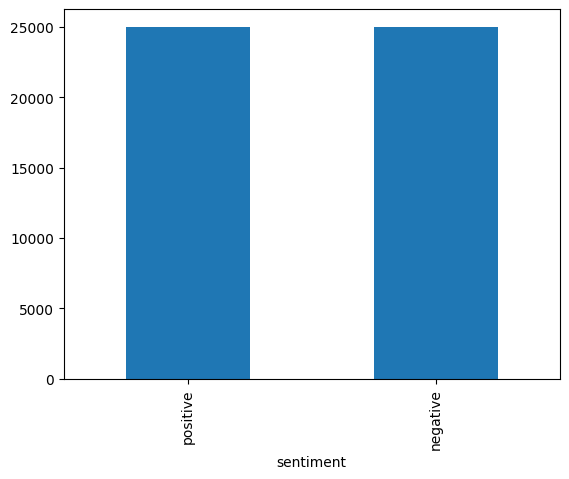

In [17]:
# Plot sentiment dari user
sentiment_label = data_movie_review["sentiment"].value_counts() # Menghitung jumlah kemunculan setiap nilai unik dalam kolom 'sentiment'
sentiment_label.plot(kind="bar") # Membuat plot batang dari hasil perhitungan
plt.show() # Menampilkan plot

# Note : ganti visualisasi percantik lagi

**Pertanyaan Kedua**
<br>
Berapa banyak kata yang biasanya di inputkan oleh user dalam mereview produk ?
<br>
<br>
Sebelum menganalisa lebih jauh mengenai review, perlu diingat bahwa bahasa manusia sangat dinamis, selain itu terdapat beberapa pattern yang didapat saat collect data

### Preprocessing Data
Dalam Preprocessing data teks dengan kasus klasifikasi maka cleaning yang akan dilakukan diantaranya dengan normalisasi data dengan cara sebagai berikut
1. Lower/Upper casing
2. Menghilangkan pattern atau karakter yang tidak diperlukan
3. Tokenization
4. Lemmatization
5. Stemming
6. Menghilangkan Stopword

### 2.1 Lower/Upper Casting
menjadi input teks menjadi 1 format penulisan, saat ini akan digunakan lower casting

In [19]:
# merubah input teks menjadi huruf kecil semua
# perintah lower() digunakan untuk merubah upper case menjadi lower case
data_movie_review["remove_punc"] = data_movie_review["review"].apply(lambda x: x.lower()) # Menerapkan fungsi lower() ke setiap elemen dalam kolom 'review' dan menyimpannya di kolom baru 'remove_punc'
data_movie_review.head() # Menampilkan 5 baris pertama dari DataFrame dengan kolom baru

,review,sentiment,remove_punc
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production. <br /><br />the...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"petter mattei's ""love in the time of money"" is..."


In [21]:
# untuk melihat bagaimana kondisi input teks dari user maka akan di perlihatkan 10 data awal untuk melihat apa saja pattern atau karakter yang tidak dibutuhkan
for i in data_movie_review["remove_punc"][:10]: # Melakukan iterasi pada 10 baris pertama kolom 'remove_punc'
  print(i) # Mencetak setiap baris teks

one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.<br /><br />the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.<br /><br />it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />i would say the main appeal of the show is due to the fac

### 2.2 Menghilangkan pattern atau karakter yang tidak diperlukan
Apabila dilihat dari 10 data pertama maka didapat beberapa pattern atau karakter yang tidak diperlukan diantaranya
1. format html
2. penggunaan tanda baca yang berlebihan
3. kemungkinan adanya format html

Untuk proses cleaning teks data akan digunakan regex untuk mendeteksi pattern serta karakter-karakter yang tidak diperlukan

In [23]:
# Mendeteksi pattern dengan Regex
# Format html
html_tag = re.compile(r'<.*?>') # Mendefinisikan pola regex untuk mendeteksi tag HTML

# Format URL
http_link = re.compile(r'https://\S+') # Mendefinisikan pola regex untuk mendeteksi URL yang dimulai dengan https://
www_link = re.compile(r'www\.\S+') # Mendefinisikan pola regex untuk mendeteksi URL yang dimulai dengan www.

# Tanda baca yang tidak diperlukan
punctuation = re.compile(r'[^\w\s]') # Mendefinisikan pola regex untuk mendeteksi karakter yang bukan huruf, angka, atau spasi

# Function untuk memproses cleaning teks data
def data_cleaning(text):
  # menghilangkan html tag
  text = re.sub(html_tag, r'', text) # Mengganti tag HTML dengan string kosong

  # menghilangkan url
  text = re.sub(http_link, r'', text) # Mengganti URL http:// dengan string kosong
  text = re.sub(www_link, r'', text) # Mengganti URL www. dengan string kosong

  # menghilangkan tanda baca
  text = re.sub(punctuation, r'', text) # Mengganti tanda baca dengan string kosong

  return text # Mengembalikan teks yang sudah dibersihkan

In [25]:
# Memanggil function data cleaning untuk kemudian diterapkan dalam dataframe
data_movie_review["remove_punc"] = data_movie_review["remove_punc"].apply(lambda x: data_cleaning(x)) # Menerapkan fungsi data_cleaning ke setiap elemen dalam kolom 'remove_punc' dan menimpanya
data_movie_review.head() # Menampilkan 5 baris pertama dari DataFrame setelah cleaning

,review,sentiment,remove_punc
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...


In [27]:
# Membandingkan 5 data awal sebelum dan sesudah cleaning
for i, j in enumerate(data_movie_review['review'][:5]): # Melakukan iterasi pada 5 baris pertama dari kolom 'review' dan mendapatkan indeks (i) serta nilai (j)
  print("sebelum : ", data_movie_review["review"][i] + "\n" + "sesudah : ", data_movie_review["remove_punc"][i] + "\n") # Mencetak teks sebelum dan sesudah pembersihan untuk perbandingan

sebelum :  One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due

### 2.3 Tokenization

Terdapat beberapa cara dalam melakukan tokenization. Berikut diberikan 3 contoh dalam mentoken kalimat

In [29]:
# Diberikan input kalimat sepeti berikut
input_text = "saat ini sedang berlangsung advanced machine learning oleh narasio data"

# 1. Menggunakan fungsi split() dimana akan mentoken kalimat berdasarkan spasi
token_1 = input_text.split(" ") # Memecah kalimat menjadi token berdasarkan spasi
print("token dengan split() : ", token_1) # Mencetak hasil tokenisasi dengan split()

# 2. Menggunakan Regex, dimana menggunakan pattern untuk mendeteksi kata
token_2 = re.findall(r"\w+", input_text) # Mencari semua urutan karakter kata (huruf, angka, underscore) dalam kalimat menggunakan regex
print("token dengan regex : ", token_2) # Mencetak hasil tokenisasi dengan regex

# 3. Menggunakan NLTK
import nltk
# nltk.download('punkt_tab') # Download the missing resource - line commented out as it caused an error and was fixed in previous turns.
token_3 = word_tokenize(input_text) # Memecah kalimat menjadi token menggunakan word_tokenize dari NLTK
print("token dengan nltk : ", token_3) # Mencetak hasil tokenisasi dengan NLTK

token dengan split() :  ['saat', 'ini', 'sedang', 'berlangsung', 'advanced', 'machine', 'learning', 'oleh', 'narasio', 'data']
token dengan regex :  ['saat', 'ini', 'sedang', 'berlangsung', 'advanced', 'machine', 'learning', 'oleh', 'narasio', 'data']
token dengan nltk :  ['saat', 'ini', 'sedang', 'berlangsung', 'advanced', 'machine', 'learning', 'oleh', 'narasio', 'data']


In [31]:
# Saat ini akan digunakan NLTK untuk tokenization input user
start_time = datetime.now() # Mencatat waktu mulai proses tokenisasi

data_movie_review["review_clean"] = data_movie_review["remove_punc"].apply(lambda x: word_tokenize(x)) # Menerapkan fungsi word_tokenize dari NLTK ke setiap elemen dalam kolom 'remove_punc' dan menyimpannya di kolom baru 'review_clean'

end_time = datetime.now() # Mencatat waktu selesai proses tokenisasi
print('Waktu yang diperlukan: {}'.format(end_time - start_time)) # Menghitung dan mencetak durasi proses tokenisasi

data_movie_review.head() # Menampilkan 5 baris pertama dari DataFrame setelah tokenisasi

Waktu yang diperlukan: 0:00:40.029759


,review,sentiment,remove_punc,review_clean
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione..."
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...,"[a, wonderful, little, production, the, filmin..."
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,..."
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,"[basically, theres, a, family, where, a, littl..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon..."


/tmp/ipython-input-828045780.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(count_words,color='Blue') # Membuat histogram distribusi jumlah kata menggunakan seaborn


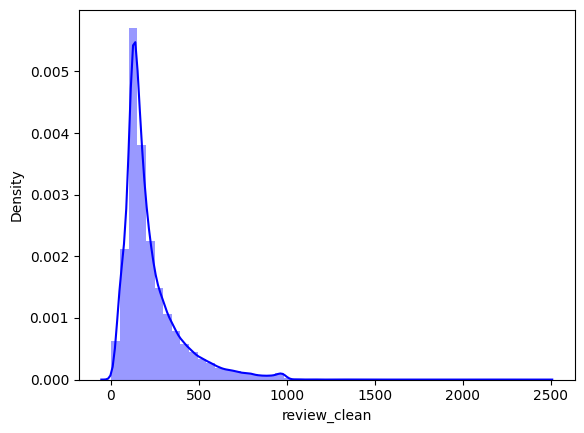

In [33]:
# Banyaknya kata yang digunakan dalam sekali review
count_words = data_movie_review["review_clean"].apply(lambda x: len(x)) # Menghitung jumlah kata dalam setiap review setelah cleaning dan tokenisasi
sns.distplot(count_words,color='Blue') # Membuat histogram distribusi jumlah kata menggunakan seaborn
plt.show() # Menampilkan plot

# Note : ganti visualisasi percantik lagi

Apakah ada perbedaan banyaknya kata-kata yang digunakan dalam review positif dan negatif?

In [35]:
# memfilter berdasarkan review positif
review_positif = data_movie_review[data_movie_review["sentiment"] == "positive"] # Membuat DataFrame baru yang hanya berisi baris dengan sentimen "positive"

# memfilter berdasarkan review negatif
review_negatif = data_movie_review[data_movie_review["sentiment"] == "negative"] # Membuat DataFrame baru yang hanya berisi baris dengan sentimen "negative"

/tmp/ipython-input-1749644140.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(count_positif_word,ax=ax1,color='Blue') # Membuat histogram distribusi jumlah kata untuk review positif pada subplot pertama
/tmp/ipython-input-1749644140.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(count_n

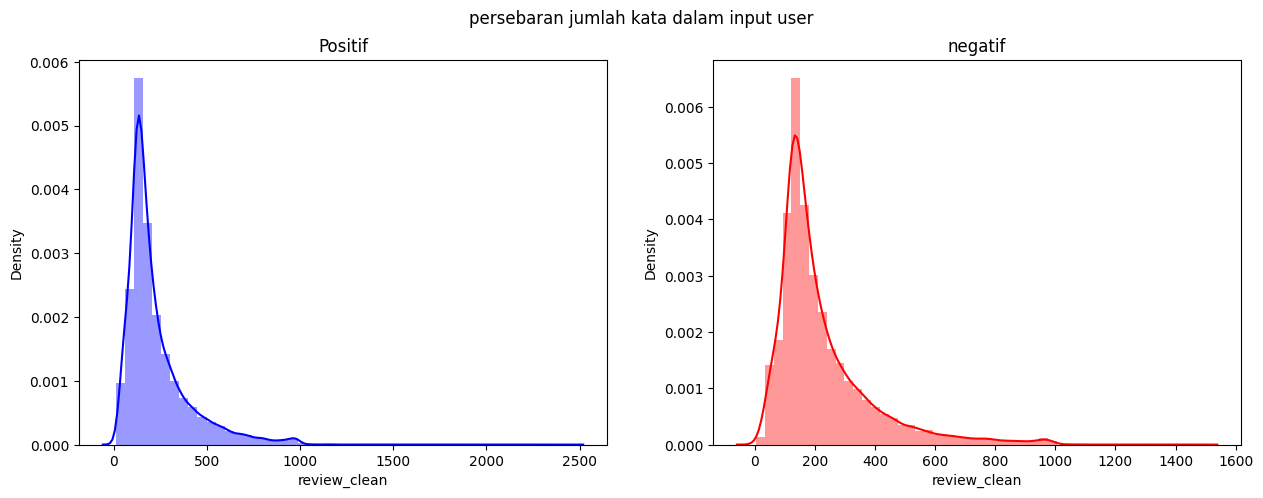

In [37]:
# memvisualisasikan banyaknya input kata yang digunakan saat mereview movie dari masing-masing label
count_positif_word = review_positif["review_clean"].apply(lambda x: len(x)) # Menghitung jumlah kata dalam setiap review positif
count_negatif_word = review_negatif["review_clean"].apply(lambda x: len(x)) # Menghitung jumlah kata dalam setiap review negatif

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,5)) # Membuat figure dan subplot dengan 1 baris dan 2 kolom
sns.distplot(count_positif_word,ax=ax1,color='Blue') # Membuat histogram distribusi jumlah kata untuk review positif pada subplot pertama
ax1.set_title("Positif") # Mengatur judul subplot pertama
sns.distplot(count_negatif_word,ax=ax2,color='Red') # Membuat histogram distribusi jumlah kata untuk review negatif pada subplot kedua
ax2.set_title("negatif") # Mengatur judul subplot kedua
fig.suptitle("persebaran jumlah kata dalam input user") # Mengatur judul utama figure
plt.show() # Menampilkan plot

### 2.4 Lemmatization
Lemmatization bertujuan untuk mempercepat waktu komputasi dan meningkatkan akurasi model. Dalam beberapa kasus lemmatization jarang digunakan karena tidak memberikan efek yang signifika terhadap akurasi model

In [39]:
# Lemmatization menggunakan NLTK
start_time = datetime.now() # Mencatat waktu mulai proses lemmatisasi

lemmatizer = WordNetLemmatizer() # Membuat objek WordNetLemmatizer
data_movie_review["review_clean"] = data_movie_review["review_clean"].apply(lambda x: [lemmatizer.lemmatize(word) for word in x]) # Menerapkan lemmatisasi pada setiap kata dalam kolom 'review_clean'

end_time = datetime.now() # Mencatat waktu selesai proses lemmatisasi
print('Waktu yang diperlukan: {}'.format(end_time - start_time)) # Menghitung dan mencetak durasi proses lemmatisasi

data_movie_review.head() # Menampilkan 5 baris pertama dari DataFrame setelah lemmatisasi

Waktu yang diperlukan: 0:00:55.086875


,review,sentiment,remove_punc,review_clean
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewer, ha, mentioned,..."
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...,"[a, wonderful, little, production, the, filmin..."
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[i, thought, this, wa, a, wonderful, way, to, ..."
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,"[basically, there, a, family, where, a, little..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon..."


### 2.5 Stemming
Tujuan dari stemming sama dengan lemmatization. Dalam penerapannya stemming menghasilkan kata dasar namun buka berarti kata tersebut sesuai dengan penulisan dalam kamus.

In [42]:
# Stemming menggunakan NLTK
start_time = datetime.now() # Mencatat waktu mulai proses stemming

ps = PorterStemmer() # Membuat objek PorterStemmer

data_movie_review["review_clean"] = data_movie_review["review_clean"].apply(lambda x: [ps.stem(word) for word in x]) # Menerapkan stemming pada setiap kata dalam kolom 'review_clean'

end_time = datetime.now() # Mencatat waktu selesai proses stemming
print('Waktu yang diperlukan: {}'.format(end_time - start_time)) # Menghitung dan mencetak durasi proses stemming

data_movie_review.head() # Menampilkan 5 baris pertama dari DataFrame setelah stemming

Waktu yang diperlukan: 0:03:01.307833


,review,sentiment,remove_punc,review_clean
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, of, the, other, review, ha, mention, tha..."
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...,"[a, wonder, littl, product, the, film, techniq..."
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[i, thought, thi, wa, a, wonder, way, to, spen..."
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,"[basic, there, a, famili, where, a, littl, boy..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,"[petter, mattei, love, in, the, time, of, mone..."


### 2.6 Menghilangkan Stopwords
stopwords merupakan list kata-kata yang tidak menimbulkan perubahan konteks kalimat apabila dihilangkan. Stopword terdiri dari kata-kata seperti kepemilikan, kalimat tanya, partikel tambahan dan lain-lain yang dapat diakses dari corpus NLTK

In [44]:
# stopword using nltk
start_time = datetime.now() # Mencatat waktu mulai proses penghapusan stopword

stop_words = set(stopwords.words('english')) # Membuat set stopword bahasa inggris

data_movie_review["review_clean"] = data_movie_review["review_clean"].apply(lambda x: [word for word in x if word not in stop_words]) # Menghapus stopword dari setiap list kata dalam kolom 'review_clean'

end_time = datetime.now() # Mencatat waktu selesai proses penghapusan stopword
print('Waktu yang diperlukan: {}'.format(end_time - start_time)) # Menghitung dan mencetak durasi proses

data_movie_review.head() # Menampilkan 5 baris pertama dari DataFrame setelah penghapusan stopword

Waktu yang diperlukan: 0:00:04.311476


,review,sentiment,remove_punc,review_clean
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, review, ha, mention, watch, 1, oz, episo..."
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...,"[wonder, littl, product, film, techniqu, veri,..."
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[thought, thi, wa, wonder, way, spend, time, h..."
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,"[basic, famili, littl, boy, jake, think, zombi..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,"[petter, mattei, love, time, money, visual, st..."


In [47]:
# Menggabungkan kata-kata menjadi satu kalimat utuh
data_movie_review["review_movie"] = data_movie_review["review_clean"].apply(lambda x: " ".join(x)) #menggabungkan kembali kata-kata dengan menambahkan spasi diantara dua kata tersebut
data_movie_review.head() # Menampilkan 5 baris pertama dari DataFrame setelah penggabungan kata

,review,sentiment,remove_punc,review_clean,review_movie
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, review, ha, mention, watch, 1, oz, episo...",one review ha mention watch 1 oz episod youll ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...,"[wonder, littl, product, film, techniqu, veri,...",wonder littl product film techniqu veri unassu...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[thought, thi, wa, wonder, way, spend, time, h...",thought thi wa wonder way spend time hot summe...
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,"[basic, famili, littl, boy, jake, think, zombi...",basic famili littl boy jake think zombi hi clo...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,"[petter, mattei, love, time, money, visual, st...",petter mattei love time money visual stun film...


In [49]:
# memfilter berdasarkan review positif
positif_review = data_movie_review[data_movie_review["sentiment"] == "positive"] # Membuat DataFrame baru yang hanya berisi baris dengan sentimen "positive"

# memfilter berdasarkan review negatif
negatif_review = data_movie_review[data_movie_review["sentiment"] == "negative"] # Membuat DataFrame baru yang hanya berisi baris dengan sentimen "negative"

In [50]:
def display_word(data, color):
  plt.subplots(figsize=(15,15)) # Membuat subplot dengan ukuran figure 15x15 inci
  word_cloud = WordCloud(width = 500, height = 300, background_color="white", contour_color=color,
                         max_words=2000, random_state=42, collocations=False) # Membuat objek WordCloud dengan parameter yang ditentukan
  word_cloud.generate(' '.join(data)) # Menghasilkan word cloud dari data teks yang digabungkan
  plt.imshow(word_cloud) # Menampilkan word cloud
  plt.axis('off') # Menyembunyikan sumbu plot
  plt.show() # Menampilkan plot

data tweet lebih dinamis, banyak slang dan variasi tata bahasa,

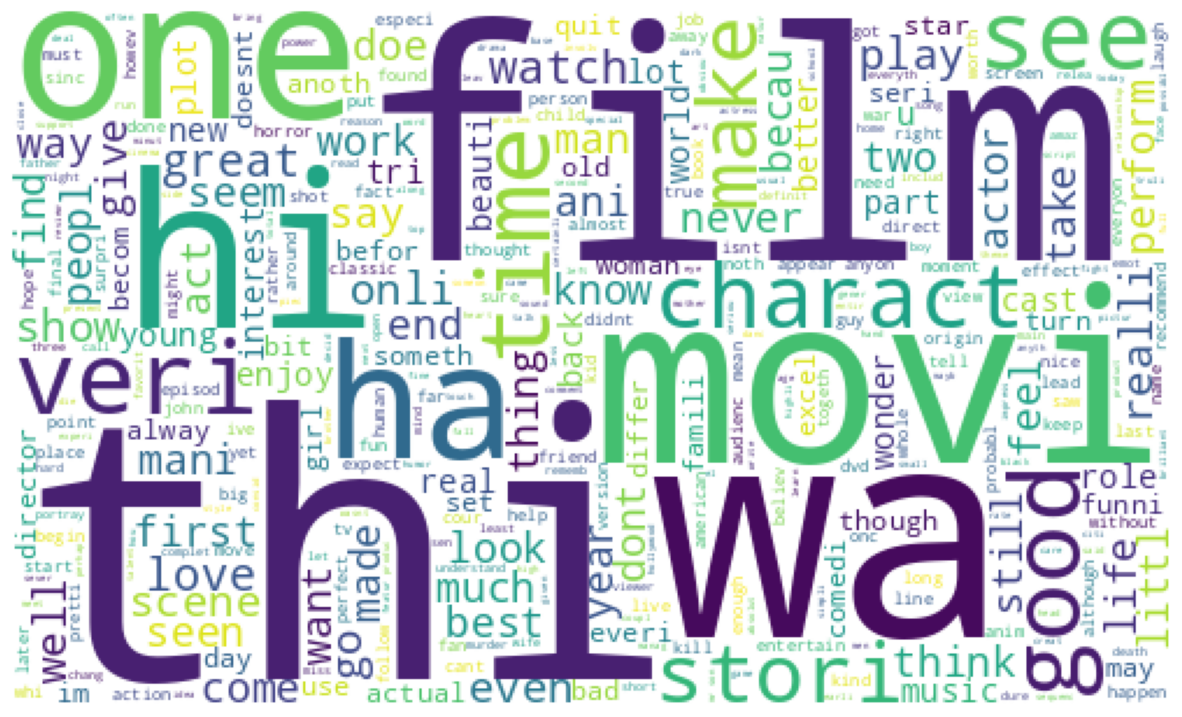

In [52]:
# wordcloud review positif
display_word(positif_review["review_movie"],'blue') # Memanggil fungsi display_word untuk menampilkan word cloud dari review positif dengan warna biru

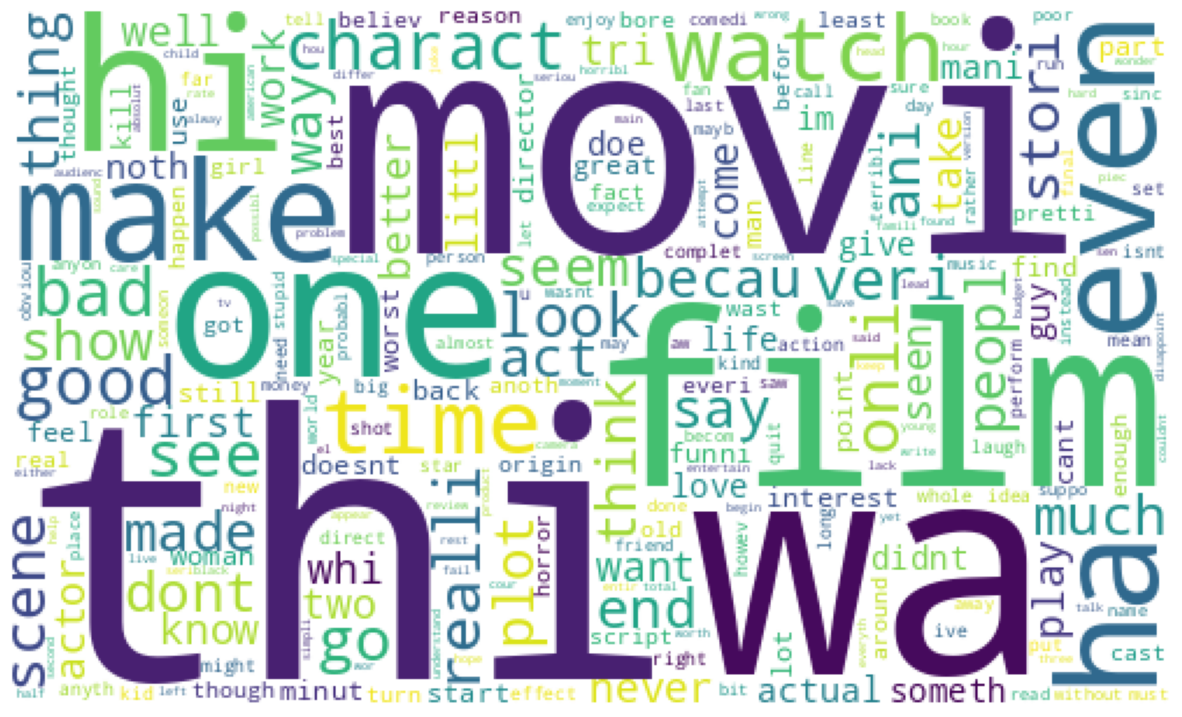

In [54]:
# wordcloud review negatif
display_word(negatif_review["review_movie"],'blue') # Memanggil fungsi display_word untuk menampilkan word cloud dari review negatif dengan warna biru

Apakah ada perbadaan penggunaan kata pada masing-masing label?

Label Encoder

In [56]:
# Mengubah label string menjadi number dengan number
label_encode = LabelEncoder() # Membuat objek LabelEncoder

In [58]:
data_movie_review["label"] = data_movie_review[["sentiment"]].apply(lambda x: label_encode.fit_transform(x)) # Menerapkan LabelEncoder pada kolom 'sentiment' untuk mengubah label string menjadi numerik dan menyimpannya di kolom baru 'label'
data_movie_review.head(10) # Menampilkan 10 baris pertama dari DataFrame dengan kolom 'label' yang baru

,review,sentiment,remove_punc,review_clean,review_movie,label
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, review, ha, mention, watch, 1, oz, episo...",one review ha mention watch 1 oz episod youll ...,1
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...,"[wonder, littl, product, film, techniqu, veri,...",wonder littl product film techniqu veri unassu...,1
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[thought, thi, wa, wonder, way, spend, time, h...",thought thi wa wonder way spend time hot summe...,1
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,"[basic, famili, littl, boy, jake, think, zombi...",basic famili littl boy jake think zombi hi clo...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,"[petter, mattei, love, time, money, visual, st...",petter mattei love time money visual stun film...,1
5,"Probably my all-time favorite movie, a story o...",positive,probably my alltime favorite movie a story of ...,"[probabl, alltim, favorit, movi, stori, selfle...",probabl alltim favorit movi stori selfless sac...,1
6,I sure would like to see a resurrection of a u...,positive,i sure would like to see a resurrection of a u...,"[sure, would, like, see, resurrect, date, seah...",sure would like see resurrect date seahunt ser...,1
7,"This show was an amazing, fresh & innovative i...",negative,this show was an amazing fresh innovative ide...,"[thi, show, wa, amaz, fresh, innov, idea, 70, ...",thi show wa amaz fresh innov idea 70 first air...,0
8,Encouraged by the positive comments about this...,negative,encouraged by the positive comments about this...,"[encourag, posit, comment, thi, film, wa, look...",encourag posit comment thi film wa look forwar...,0
9,If you like original gut wrenching laughter yo...,positive,if you like original gut wrenching laughter yo...,"[like, origin, gut, wrench, laughter, like, th...",like origin gut wrench laughter like thi movi ...,1


### TF-IDF

In [60]:
# mendefinisikan tf-idf vectorizer
tfidf_vect = TfidfVectorizer() # Menginisialisasi objek TfidfVectorizer
# ubah teks pada "review_movie" menjadi document-term matrix
# dengan value diperoleh dari tf-idf
train_tfidf = tfidf_vect.fit_transform(data_movie_review["review_movie"].values.tolist()) # Mengubah teks pada kolom "review_movie" menjadi matriks document-term menggunakan TF-IDF
# cek dimensi dari train_tfidf
train_tfidf.shape # Menampilkan dimensi dari matriks train_tfidf (jumlah dokumen, jumlah fitur/kata unik)

(50000, 179315)

In [62]:
# lakukan train-test split pada train_tfidf
X_train, X_test, y_train, y_test = train_test_split(
    # variabel prediktor diambil dari train_tfidf
    train_tfidf,
    # variabel target diambil dari kolom "label" pada "data_movie_review"
    data_movie_review['label'],
    # ambil 30% dari dataset sebagai test_size
    test_size=0.3,
    # gunakan 42 untuk seeding
    random_state=42
)

In [64]:
# Modeling dengan Multinomial Naive Bayes
clf = MultinomialNB().fit(X_train, y_train)
# buat prediksi dari model
predicted= clf.predict(X_test)
# cek akurasi model
print("MultinomialNB Accuracy:",metrics.accuracy_score(y_test, predicted))

MultinomialNB Accuracy: 0.8592666666666666


In [66]:
# mendefinisikan tf-idf vectorizer baru
tfidf_vect_1 = TfidfVectorizer()
# ubah teks pada "remove_punc" menjadi document-term matrix
# dengan value diperoleh dari tf-idf
train_tfidf_1 = tfidf_vect_1.fit_transform(data_movie_review["remove_punc"].values.tolist())
# cek dimensi dari train_tfidf_1
train_tfidf_1.shape

(50000, 221910)

In [67]:
# lakukan train-test split pada train_tfidf_1
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    # variabel prediktor diambil dari train_tfidf_1
    train_tfidf_1,
    # variabel target diambil dari kolom "label" pada "data_movie_review"
    data_movie_review['label'],
    # ambil 30% dari dataset sebagai test_size
    test_size=0.3,
    # gunakan 42 untuk seeding
    random_state=42
)

In [68]:
# Modeling dengan Multinomial Naive Bayes
clf_1 = MultinomialNB().fit(X_train_1, y_train_1)
# buat prediksi dari model
predicted_1= clf_1.predict(X_test_1)
# cek akurasi model
print("MultinomialNB Accuracy dengan teks dari remove_punc:", metrics.accuracy_score(y_test_1, predicted_1))

MultinomialNB Accuracy dengan teks dari remove_punc: 0.8614


In [69]:
# mendefinisikan tf-idf vectorizer dengan n-gram dari 1 sampai 2
tfidf_vect_1 = TfidfVectorizer(ngram_range=(1,3))
# ubah teks pada "remove_punc" menjadi document-term matrix
# dengan value diperoleh dari tf-idf
train_tfidf_1 = tfidf_vect_1.fit_transform(data_movie_review["remove_punc"].values.tolist())
# cek dimensi dari train_tfidf_1
train_tfidf_1.shape

(50000, 9524505)

In [70]:
# lakukan train-test split pada train_tfidf_1
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    # variabel prediktor diambil dari train_tfidf_1
    train_tfidf_1,
    # variabel target diambil dari kolom "label" pada "data_movie_review"
    data_movie_review['label'],
    # ambil 30% dari dataset sebagai test_size
    test_size=0.3,
    # gunakan 42 untuk seeding
    random_state=42
)

In [71]:
# Modeling dengan Multinomial Naive Bayes
clf_1 = MultinomialNB().fit(X_train_1, y_train_1)
# buat prediksi dari model
predicted_1= clf_1.predict(X_test_1)
# cek akurasi dari model
print("MultinomialNB Accuracy dengan n_gram:",metrics.accuracy_score(y_test_1, predicted_1))

MultinomialNB Accuracy dengan n_gram: 0.8926666666666667
